In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from LSSVMClassifier2 import LSSVMClassification
from sklearn.datasets import load_iris


In [20]:
#df = pd.read_excel("chemical_fingerprint.xlsx") #lezen van fingerprint

#-------


#X = df.drop(columns=["Eg", "Class"])
#y = df["Class"]
#------------------

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape) #controle

#---------------

model = LSSVMClassification(
    gamma=1,
    kernel="rbf",
    sigma=1
)

#-----------------

# Training
model.fit(X_train, y_train)

#------------------

# Predicition 
y_pred = model.predict(X_test)

#------------------

# Accuracy 
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

# lage accuracy: model is aan het gokken 

(5083, 81)
(1271, 81)
Accuracy: 0.5334382376081825


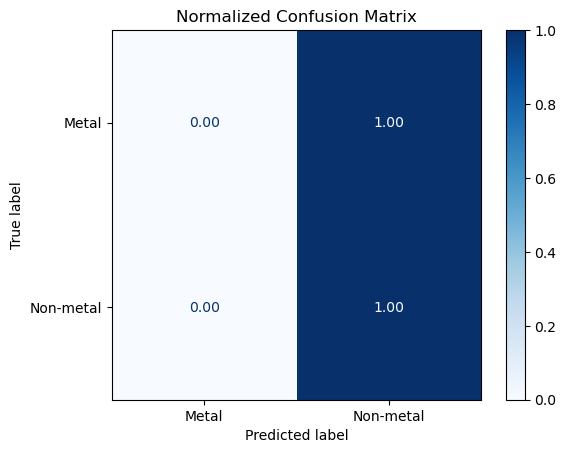

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       593
           1       0.53      1.00      0.70       678

    accuracy                           0.53      1271
   macro avg       0.27      0.50      0.35      1271
weighted avg       0.28      0.53      0.37      1271



C:\Users\sabas\anaconda3\envs\2026.1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sabas\anaconda3\envs\2026.1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sabas\anaconda3\envs\2026.1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [21]:
cm = confusion_matrix(
    y_test, 
    y_pred,
    normalize="true"
) #confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Metal", "Non-metal"]
)

disp.plot(
    cmap="Blues",
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix")
plt.show()
print(classification_report(y_test, y_pred))


In [22]:
#problemen: classifier voorspelt alles als +1 (Non-metal), verhouding -1/1 = 0.533 
#kan hyperparameter probleem zijn: sigma of gamma 
#controle of classifier wel degelijk verschillende voorspellingen maakt

print(np.unique(y_pred))
model.fit(X_train, y_train)

print(model.intercept_) 

print(model.coef_[:10])


[1.]
1.0000000000000044
[-8.21565038e-15  1.77635684e-15 -6.16173779e-15 -3.44169138e-15
 -3.99680289e-15  1.44328993e-15  5.55111512e-16  4.77395901e-15
 -4.21884749e-15 -3.10862447e-15]


In [23]:
# intercept ~ 1, alfa ~ 0, alles voorspelt van +1: A^-1B klopt niet, probleem zoeken bij _OptimizeParams()
